## Basic delay equation simulations of PFThalamus-Striatum recurrencd

In [1]:
%load_ext autoreload
%autoreload 2 --print

In [2]:

from cmap import Colormap
from datetime import datetime
from mplutil import util as vu
import matplotlib.pyplot as plt
from pathlib import Path
from typing import TypedDict

import tqdm
import numpy as np
from numpy import linalg as la
import os
import joblib as jl
import time
import seaborn as sns

In [3]:
from dynrn.viz import styles
from dynrn.viz.styles import getc
t20 = lambda x: getc(f"seaborn:tab20{x}")
colors, plotter = styles.init_plt(
    Path('../plots/notebook/diffdiff-pft').resolve(),
    fmt = 'pdf', display=False)
plot_root = Path(plotter.plot_dir)

### Define linear recurrent system
$$\begin{align*}
s^{d/i}_{t+1} &= W^\text {d/i} x_{t} + As^{\text{pf}}_t &
s^\text{nr}_{t+1} &= Us^\text i_{t-\Delta_\text i} - \gamma Vs^\text d_{t-\Delta_\text d} \\
\delta_{t+1} &= D(r_t - s^\text{nr}_t) &
s^{\text{pf}}_{t+1} &= Px_t -Q s^{nr}_t
\end{align*}$$

In [4]:
class PfStriatumParams(TypedDict):
    # population sizes
    Nx: int
    Nd: int
    Ni: int
    Nsnr: int
    Npf: int
    # synaptic strengths
    Wd: np.ndarray  # (..., Nd, Nx)
    Wi: np.ndarray  # (..., Ni, nx)
    Ad: np.ndarray  # (..., Nd, Npf)
    Ai: np.ndarray  # (..., Ni, Npf)
    V: np.ndarray  # (..., Nsnr, Nd)
    U: np.ndarray  # (..., Nsnr, Ni)
    P: np.ndarray  # (..., Npf, Nx)
    Q: np.ndarray  # (..., Npf, Nsnr)
    # delays
    Delta_d: int  # delay along direct pathway
    Delta_i: int  # delay along indirect pathway


class PfStriatumHistory(TypedDict):
    d: np.ndarray  # (..., t, Nd)
    i: np.ndarray  # (..., t, Ni)
    snr: np.ndarray  # (..., t, Nsnr)
    pf: np.ndarray  # (..., t, Npf)
    x: np.ndarray  # (..., t, Nx)


def _concat_hist(*hists):
    return {k: np.concatenate([h[k] for h in hists]) for k in hists[0]}

def _set_hist(hist, t_obj, value):
    for k, arr in hist.items():
        arr[..., t_obj, :] = value[k]

def _slice_hist(hist, t_obj):
    return {k: arr[..., t_obj, :] for k, arr in hist.items()}

def _len_hist(hist):
    return list(hist.values())[0].shape[-2]

In [5]:
def pfstriatum_step_linear(
    next_x: np.ndarray, hist: PfStriatumHistory, params: PfStriatumParams
):
    """
    Parameters
    ----------
    next_x: shape (..., Nx)
        Value of x_{t+1} to insert into the history.
    Returns
    -------
    next_step : PFStriatumHistory
        With time length == 1
    """
    # simple values at time t+1 only depending on time t
    spf = params["P"] @ hist["x"][..., -1, :] - params["Q"] @ hist["snr"][..., -1, :]
    d = params["Wd"] @ hist["x"][..., -1, :] + params["Ad"] @ hist["pf"][..., -1, :]
    i = params["Wi"] @ hist["x"][..., -1, :] + params["Ai"] @ hist["pf"][..., -1, :]
    # delay values at time t+1 depending on times before time t
    d_delayed = hist["d"][..., -1 - params["Delta_d"], :]
    i_delayed = hist["i"][..., -1 - params["Delta_i"], :]
    snr = params["U"] @ d_delayed - params["V"] @ i_delayed
    # construct as history object
    return PfStriatumHistory(
        pf=spf[..., None, :],
        d=d[..., None, :],
        i=i[..., None, :],
        snr=snr[..., None, :],
        x=next_x[..., None, :],
    )


def pfstriatum_sim(
    step_func, x: np.ndarray, hist: PfStriatumHistory, params: PfStriatumParams, progress=False
):
    """
    Parameters
    ----------
    x : (..., t, Nx)
    """
    nt = x.shape[-2]
    t0 = _len_hist(hist)
    ret_hist = _concat_hist(
        hist,
        {k: np.zeros(hist[k].shape[:-2] + (nt, + hist[k].shape[-1])) for k in hist},
    )
    pbar = tqdm.trange(nt) if progress else range(nt)
    for step in pbar:
        curr_hist = _slice_hist(ret_hist, slice(None, step + t0))
        next_step = step_func(x[..., step, :], curr_hist, params)
        _set_hist(ret_hist, [step + t0], next_step)

    return _slice_hist(ret_hist, slice(t0, None))


def pfstriatum_hist_zero(length, params, batch=()):
    return PfStriatumHistory(
        pf=np.zeros(batch + (length, params["Npf"])),
        d=np.zeros(batch + (length, params["Nd"])),
        i=np.zeros(batch + (length, params["Ni"])),
        snr=np.zeros(batch + (length, params["Nsnr"])),
        x=np.zeros(batch + (length, params["Nx"])),
    )


pfs_params_id = lambda n, decay, Dd, Di: PfStriatumParams(
    Npf=n,
    Nd=n,
    Ni=n,
    Nsnr=n,
    Nx=n,
    Wd=decay * np.eye(n),
    Wi=decay * np.eye(n),
    Ad=decay * np.eye(n),
    Ai=decay * np.eye(n),
    U=decay * np.eye(n),
    V=decay * np.eye(n),
    P=decay * np.eye(n),
    Q=decay * np.eye(n),
    Delta_d=Dd,
    Delta_i=Di,
)

### Simulation of basic linear system

In [106]:
params = pfs_params_id(1, 0.5, 10, 20)
init_hist = pfstriatum_hist_zero(40, params)
nt = 100
impulse_time = 10
impulse = np.zeros([nt, params['Nx']])
impulse[impulse_time] = 1
sim_hist = pfstriatum_sim(pfstriatum_step_linear, impulse, init_hist, params)

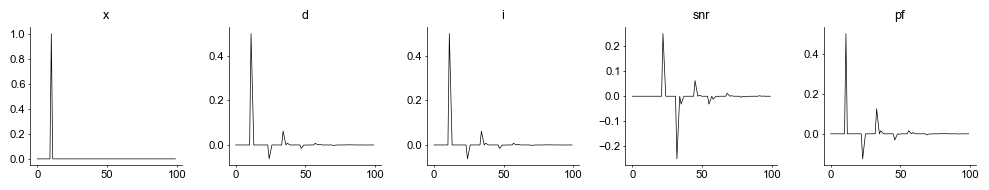

In [107]:
fig, ax = plt.subplots(1, 5, figsize = (10, 2))
ax[0].plot(sim_hist['x'][:, 0], 'k-', lw = 0.5)
ax[0].set_title("x")
ax[1].plot(sim_hist['d'][:, 0], 'k-', lw = 0.5)
ax[1].set_title("d")
ax[2].plot(sim_hist['i'][:, 0], 'k-', lw = 0.5)
ax[2].set_title("i")
ax[3].plot(sim_hist['snr'][:, 0], 'k-', lw = 0.5)
ax[3].set_title("snr")
ax[4].plot(sim_hist['pf'][:, 0], 'k-', lw = 0.5)
ax[4].set_title("pf")
plotter.finalize(fig, None)

### Alternate PFStriatum models

#### Divisive inhibition of PF

In [129]:
def pfstriatum_step_divpf(
    next_x: np.ndarray, hist: PfStriatumHistory, params: PfStriatumParams
):
    """
    Parameters
    ----------
    next_x: shape (..., Nx)
        Value of x_{t+1} to insert into the history.
    Returns
    -------
    next_step : PFStriatumHistory
        With time length == 1
    """
    # simple values at time t+1 only depending on time t
    spf_e = params["P"] @ hist["x"][..., -1, :]
    spf_i = params["Q"] @ hist["snr"][..., -1, :]
    spf = spf_e / (1 + spf_e + spf_i)
    d = params["Wd"] @ hist["x"][..., -1, :] + params["Ad"] @ hist["pf"][..., -1, :]
    i = params["Wi"] @ hist["x"][..., -1, :] + params["Ai"] @ hist["pf"][..., -1, :]
    # delay values at time t+1 depending on times before time t
    d_delayed = hist["d"][..., -1 - params["Delta_d"], :]
    i_delayed = hist["i"][..., -1 - params["Delta_i"], :]
    snr = params["U"] @ i_delayed - params["V"] @ d_delayed
    # construct as history object
    return PfStriatumHistory(
        pf=spf[..., None, :],
        d=d[..., None, :],
        i=i[..., None, :],
        snr=snr[..., None, :],
        x=next_x[..., None, :],
    )

In [102]:
params = pfs_params_id(1, 0.5, 10, 20)
params_nopf = {**params, 'Ad': params['Ad'] * 0, 'Ai': params['Ai'] * 0}
init_hist = pfstriatum_hist_zero(40, params)
init_hist['x'] = init_hist['x'] + 1
nt = 400
impulse_time = 100
impulse = np.ones([nt, params['Nx']])
impulse[impulse_time] = 2
impulse[impulse_time*2 : impulse_time*2 + 20] = 2
impulse[impulse_time*3 : impulse_time*3 + 40] = np.linspace(1, 2, 40)[:, None]

sim_hist = pfstriatum_sim(pfstriatum_step_divpf, impulse, init_hist, params)
sim_hist_nopf = pfstriatum_sim(pfstriatum_step_divpf, impulse, init_hist, params_nopf)

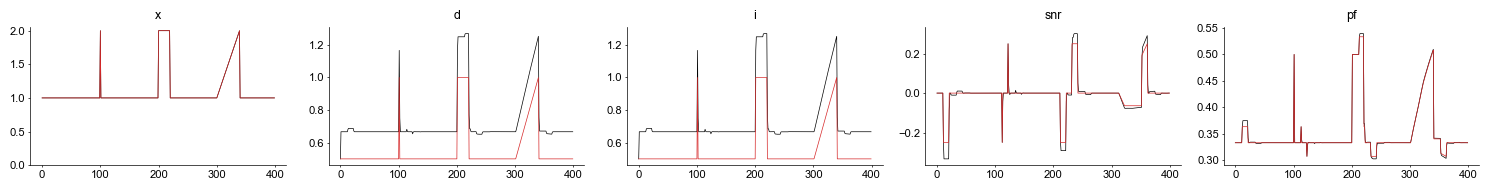

In [103]:
fig, ax = plt.subplots(1, 5, figsize = (15, 2))
ax[0].plot(sim_hist['x'][:, 0], 'k-', lw = 0.5)
ax[0].plot(sim_hist_nopf['x'][:, 0], 'C3-', lw = 0.5)
ax[0].set_title("x")
ax[0].set_ylim(0, None)
ax[1].plot(sim_hist['d'][:, 0], 'k-', lw = 0.5)
ax[1].plot(sim_hist_nopf['d'][:, 0], 'C3-', lw = 0.5)
ax[1].set_title("d")
ax[2].plot(sim_hist['i'][:, 0], 'k-', lw = 0.5)
ax[2].plot(sim_hist_nopf['i'][:, 0], 'C3-', lw = 0.5)
ax[2].set_title("i")
ax[3].plot(sim_hist['snr'][:, 0], 'k-', lw = 0.5)
ax[3].plot(sim_hist_nopf['snr'][:, 0], 'C3-', lw = 0.5)
ax[3].set_title("snr")
ax[4].plot(sim_hist['pf'][:, 0], 'k-', lw = 0.5)
ax[4].plot(sim_hist_nopf['pf'][:, 0], 'C3-', lw = 0.5)
ax[4].set_title("pf")
plotter.finalize(fig, None)

#### Small PF, SNr

$x$ must be bigger, simplest case is $N_x=2$.
1. Retain size of SNr. Project all $x_i$ to one PF unit.
    - Effect of activity in one $x$ channel on other channels.
        - _Induces some correlation in channels receiving input from the same PF
          neuron simply through propagation of $x$._
    - Does this change if the sum is not balanced?
        - _Not meaningfully beyond increasing said correlation._
2. Shrink SNr also, but keep striatum size
    - _These signals get summed in the smaller PF anyway._
3. Strong recurrence.
    - _Just longer oscillations, until instability_

In [164]:
nt = 1000
impulse_time = 200

# impulses / ramps in first channel
impulse = np.ones([nt, 2])
impulse[impulse_time, 0] = 2
impulse[impulse_time*2 : impulse_time*2 + 20, 0] = 2
impulse[impulse_time*3 : impulse_time*3 + 40, 0] = np.linspace(1, 2, 40)

tonic = np.ones([nt, 2])

In [136]:
params = pfs_params_id(2, 0.5, 10, 20)
params["Q"] = 0.25 * np.array([[1, 1]])
params["P"] = 0.25 * np.array([[1, 1]])
params["Ad"] = 0.5 * np.array([[1], [1]])
params["Ai"] = 0.5 * np.array([[1], [1]])
params["Npf"] = 1
params_nopf = {**params, 'Ad': params['Ad'] * 0, 'Ai': params['Ai'] * 0}

init_hist = pfstriatum_hist_zero(params['Delta_i'] + 10, params)
init_hist['x'] = init_hist['x'] + 1

sim_hist = pfstriatum_sim(pfstriatum_step_divpf, impulse, init_hist, params)
sim_hist_nopf = pfstriatum_sim(pfstriatum_step_divpf, impulse, init_hist, params_nopf)

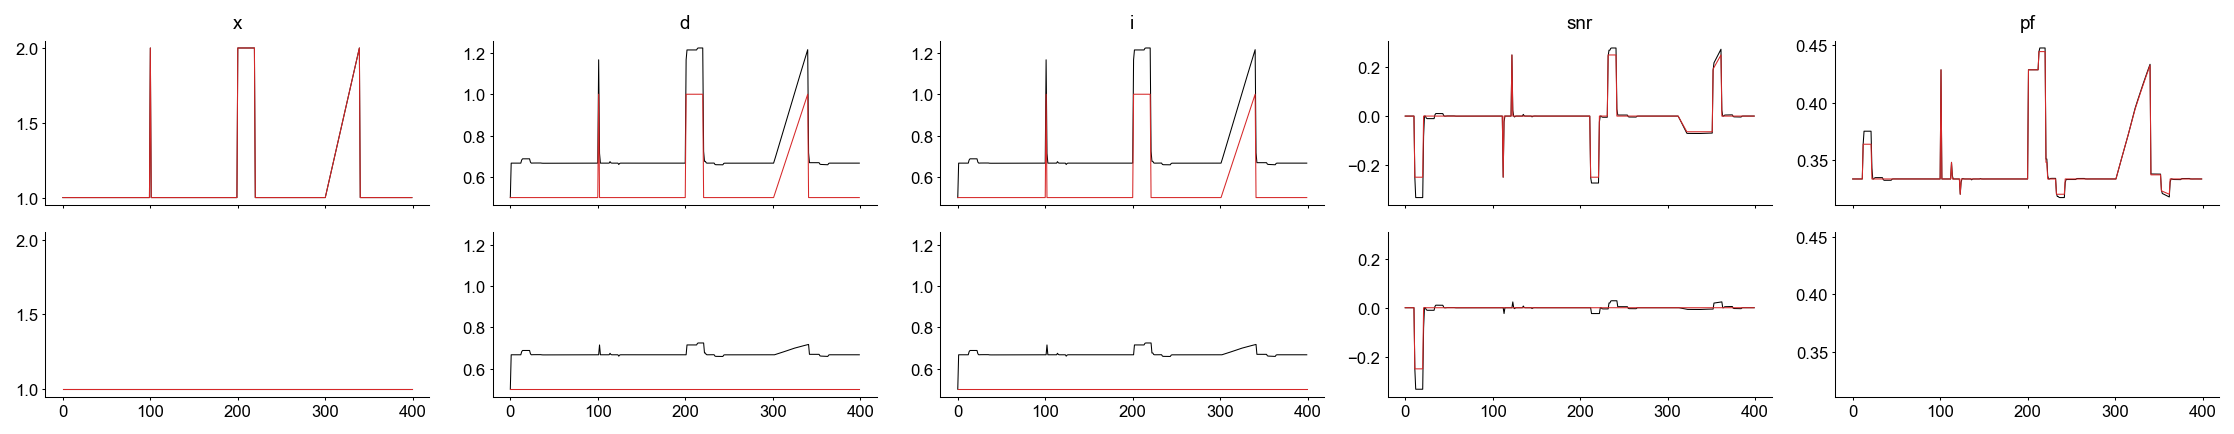

In [137]:
fig, ax = plt.subplots(2, 5, figsize = (15, 3), sharey='col', dpi=150, sharex=True)
for j, k in enumerate(["x", "d", "i", "snr", "pf"]):
    for i in range(min(len(ax), sim_hist[k].shape[-1])):
        ax[i, j].plot(sim_hist[k][:, i], 'k-', lw = 0.5)
        ax[i, j].plot(sim_hist_nopf[k][:, i], 'C3-', lw = 0.5)
        if i == 0:
            ax[i, j].set_title(k)
plotter.finalize(fig, None)

In [134]:
params = pfs_params_id(2, 0.5, 10, 20)
params["Q"] = 0.25 * np.array([[1, 1]])
params["P"] = 0.25 * np.array([[1, 1]])
params["Ad"] = 0.5 * np.array([[1], [2]])
params["Ai"] = 0.5 * np.array([[1], [2]])
params["Npf"] = 1
params_nopf = {**params, 'Ad': params['Ad'] * 0, 'Ai': params['Ai'] * 0}

init_hist = pfstriatum_hist_zero(params['Delta_i'] + 10, params)
init_hist['x'] = init_hist['x'] + 1


sim_hist = pfstriatum_sim(pfstriatum_step_divpf, impulse, init_hist, params)
sim_hist_nopf = pfstriatum_sim(pfstriatum_step_divpf, impulse, init_hist, params_nopf)

Ad_1, Ai_1 = 1


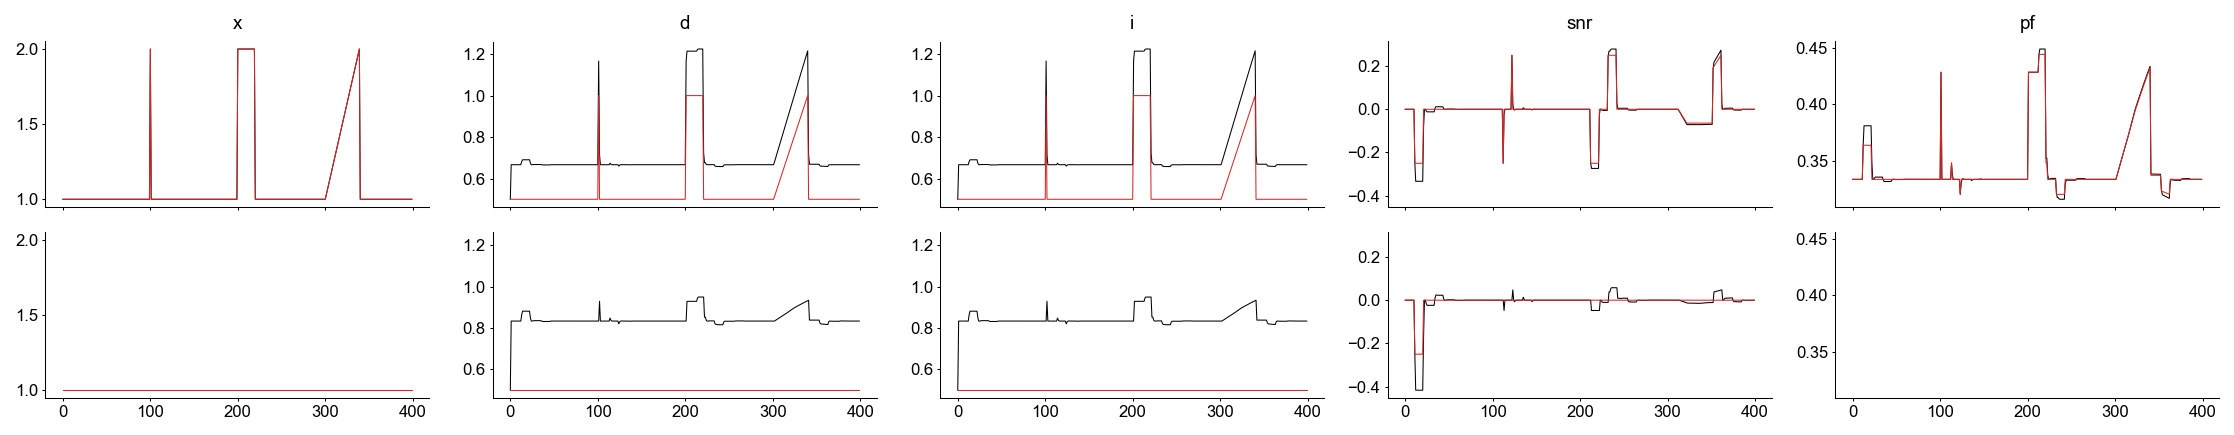

In [135]:
fig, ax = plt.subplots(2, 5, figsize = (15, 3), sharey='col', dpi=150, sharex=True)
for j, k in enumerate(["x", "d", "i", "snr", "pf"]):
    for i in range(min(len(ax), sim_hist[k].shape[-1])):
        ax[i, j].plot(sim_hist[k][:, i], 'k-', lw = 0.5)
        ax[i, j].plot(sim_hist_nopf[k][:, i], 'C3-', lw = 0.5)
        if i == 0:
            ax[i, j].set_title(k)

print("Ad_1, Ai_1 = 1")
plotter.finalize(fig, None)

In [171]:
# --- Small PF and SNr, balanced channels, strong recurrence

params = pfs_params_id(2, 0.5, 10, 20)
params["Q"] = 0.5 * np.array([[1]])
params["P"] = 0.25 * np.array([[1, 1]])
params["Ad"] = 4 * np.array([[1], [1]])
params["Ai"] = 4 * np.array([[1], [1]])
params["Npf"] = 1
params["V"] = 0.5 * np.array([[1, 1]])
params["U"] = 0.5 * np.array([[1, 1]])
params["Nsnr"] = 1
params_nopf = {**params, 'Ad': params['Ad'] * 0, 'Ai': params['Ai'] * 0}

init_hist = pfstriatum_hist_zero(params['Delta_i'] + 10, params)
init_hist['x'] = init_hist['x'] + 1

init_hist_nopf = _slice_hist(pfstriatum_sim(pfstriatum_step_divpf, tonic, init_hist, params_nopf), slice(-40, None))
init_hist = _slice_hist(pfstriatum_sim(pfstriatum_step_divpf, tonic, init_hist, params), slice(-40, None))

impulse_only = impulse.copy()
impulse_only[impulse_time + 1:, 0] = 1
sim_hist = pfstriatum_sim(pfstriatum_step_divpf, impulse_only, init_hist, params)
sim_hist_nopf = pfstriatum_sim(pfstriatum_step_divpf, impulse_only, init_hist_nopf, params_nopf)

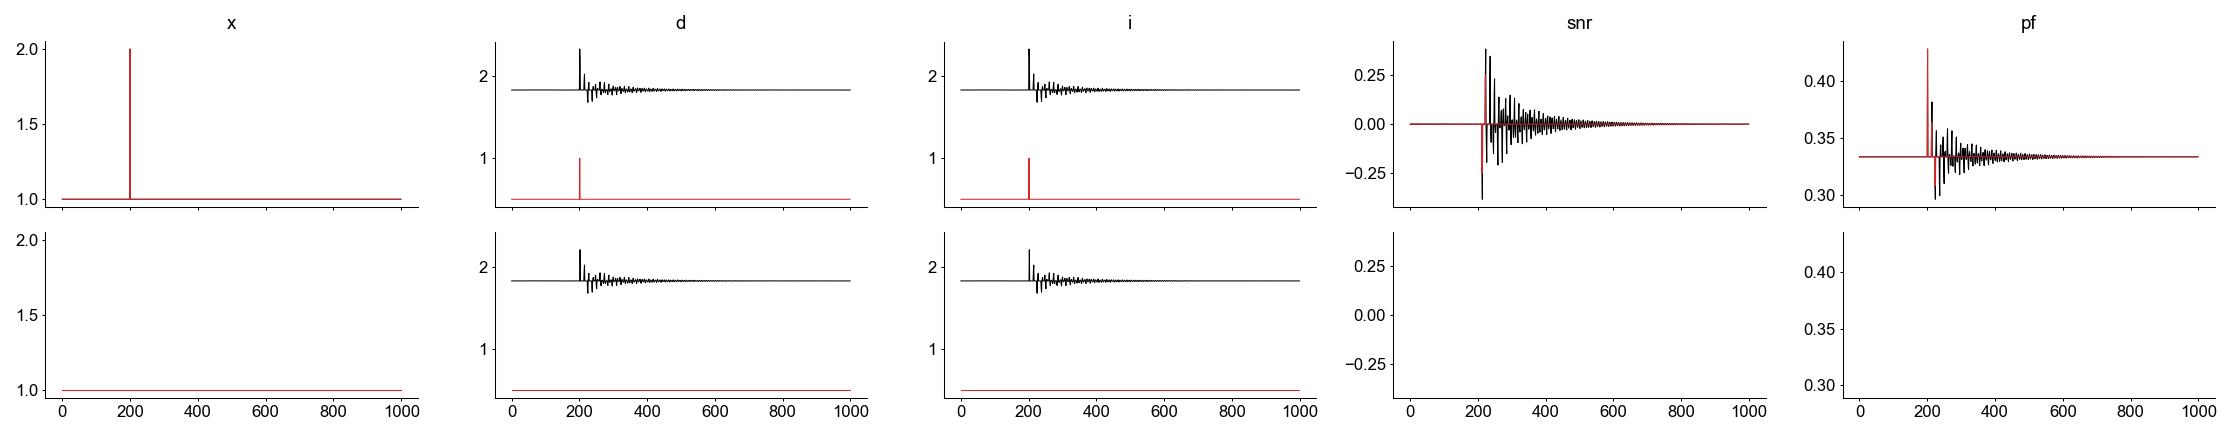

In [172]:
fig, ax = plt.subplots(2, 5, figsize = (15, 3), sharey='col', dpi=150, sharex=True)
for j, k in enumerate(["x", "d", "i", "snr", "pf"]):
    for i in range(min(len(ax), sim_hist[k].shape[-1])):
        ax[i, j].plot(sim_hist[k][:, i], 'k-', lw = 0.5)
        ax[i, j].plot(sim_hist_nopf[k][:, i], 'C3-', lw = 0.5)
        if i == 0:
            ax[i, j].set_title(k)
plotter.finalize(fig, None)

#### ST plasticity at PF-Str synapses

In [7]:
def pfstriatum_step_dtpf(
    next_x: np.ndarray, hist: PfStriatumHistory, params: PfStriatumParams
):
    """
    Parameters
    ----------
    next_x: shape (..., Nx)
        Value of x_{t+1} to insert into the history.
    Returns
    -------
    next_step : PFStriatumHistory
        With time length == 1
    """
    # simple values at time t+1 only depending on time t
    pf_e = params["P"] @ hist["x"][..., -1, :]
    pf_i = params["Q"] @ hist["snr"][..., -1, :]
    pf = pf_e / (1 + pf_e + pf_i)
    dtpf = np.clip(0, None, pf - hist["pf"][..., -1, :])
    d = params["Wd"] @ hist["x"][..., -1, :] + params["Ad"] @ dtpf
    i = params["Wi"] @ hist["x"][..., -1, :] + params["Ai"] @ dtpf
    # delay values at time t+1 depending on times before time t
    d_delayed = hist["d"][..., -1 - params["Delta_d"], :]
    i_delayed = hist["i"][..., -1 - params["Delta_i"], :]
    snr = params["U"] @ i_delayed - params["V"] @ d_delayed
    # construct as history object
    return PfStriatumHistory(
        pf=pf[..., None, :],
        d=d[..., None, :],
        i=i[..., None, :],
        snr=snr[..., None, :],
        x=next_x[..., None, :],
    )

In [8]:
params = pfs_params_id(1, 0.5, 10, 20)
params_nopf = {**params, 'Ad': params['Ad'] * 0, 'Ai': params['Ai'] * 0}
init_hist = pfstriatum_hist_zero(40, params)
init_hist['x'] = init_hist['x'] + 1
nt = 400
impulse_time = 100
impulse = np.ones([nt, params['Nx']])
impulse[impulse_time] = 2
impulse[impulse_time*2 : impulse_time*2 + 20] = 2
impulse[impulse_time*3 : impulse_time*3 + 40] = np.linspace(1, 2, 40)[:, None]

sim_hist = pfstriatum_sim(pfstriatum_step_dtpf, impulse, init_hist, params)
sim_hist_nopf = pfstriatum_sim(pfstriatum_step_dtpf, impulse, init_hist, params_nopf)

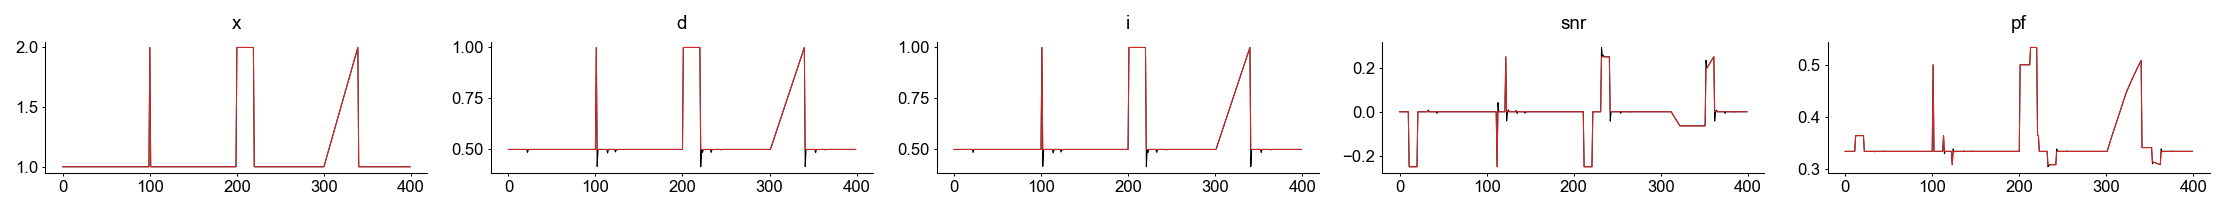

In [11]:
fig, ax = plt.subplots(1, 5, figsize = (15, 1.5), sharey='col', dpi=150, sharex=True)
ax = ax[None]
for j, k in enumerate(["x", "d", "i", "snr", "pf"]):
    for i in range(min(len(ax), sim_hist[k].shape[-1])):
        ax[i, j].plot(sim_hist[k][:, i], 'k-', lw = 0.5)
        ax[i, j].plot(sim_hist_nopf[k][:, i], 'C3-', lw = 0.5)
        if i == 0:
            ax[i, j].set_title(k)
plotter.finalize(fig, None)